In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [ ]:
# Simulate model predictions on 1000 test samples
np.random.seed(42)

In [5]:
# Model A: 82% accuracy
model_a_correct = np.random.binomial(n=1, p=0.82, size=1000)

# Model B: 85% accuracy
model_b_correct = np.random.binomial(n=1, p=0.85, size=1000)

In [6]:
print(f"Model A: {model_a_correct.mean():.3f} accuracy")
print(f"Model B: {model_b_correct.mean():.3f} accuracy")
print(f"Difference: {(model_b_correct.mean() - model_a_correct.mean()):.3f}")

Model A: 0.826 accuracy
Model B: 0.848 accuracy
Difference: 0.022


In [7]:
def two_proportion_z_test(successes_a, n_a, successes_b, n_b):
    """
    Test if two proportions are significantly different.
    
    H0 (null hypothesis): p_a = p_b (no difference)
    H1 (alternative): p_a ≠ p_b (there is a difference)
    """
    p_a = successes_a / n_a
    p_b = successes_b / n_b
    
    # Pooled proportion (assuming H0 is true)
    p_pool = (successes_a + successes_b) / (n_a + n_b)
    
    # Standard error
    se = np.sqrt(p_pool * (1 - p_pool) * (1/n_a + 1/n_b))
    
    # Z-statistic
    z = (p_b - p_a) / se
    
    # P-value (two-tailed)
    p_value = 2 * (1 - stats.norm.cdf(abs(z)))
    
    return {
        'z_statistic': z,
        'p_value': p_value,
        'significant_at_0.05': p_value < 0.05
    }

# Run the test
result = two_proportion_z_test(
    successes_a=model_a_correct.sum(),
    n_a=len(model_a_correct),
    successes_b=model_b_correct.sum(),
    n_b=len(model_b_correct)
)

print("\n" + "="*50)
print("HYPOTHESIS TEST RESULTS")
print("="*50)
print(f"Z-statistic: {result['z_statistic']:.3f}")
print(f"P-value: {result['p_value']:.4f}")
print(f"Significant at α=0.05? {result['significant_at_0.05']}")
print("\nInterpretation:")
if result['significant_at_0.05']:
    print("✓ Model B is statistically better than Model A")
else:
    print("✗ Cannot conclude Model B is better (might be random noise)")


HYPOTHESIS TEST RESULTS
Z-statistic: 1.332
P-value: 0.1829
Significant at α=0.05? False

Interpretation:
✗ Cannot conclude Model B is better (might be random noise)


In [8]:
# Visualize p-value intuition
np.random.seed(42)

In [19]:
# Null hypothesis: Models are equal (both 82% accuracy)
null_distribution = []
for _ in range(10000):
    # Simulate both models having same accuracy
    a = np.random.binomial(n=1, p=0.82, size=1000).mean()
    b = np.random.binomial(n=1, p=0.82, size=1000).mean()
    null_distribution.append(b - a)

null_distribution = np.array(null_distribution)

In [20]:
# Observed difference (when Model B is actually 85%)
observed_diff = 0.03  # 85% - 82%

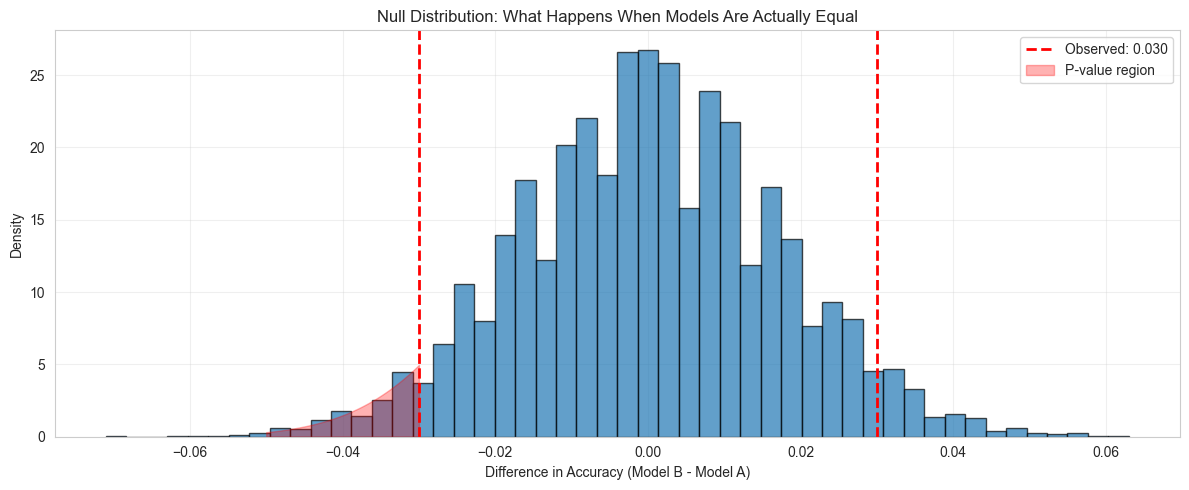

In [21]:
# Plot
plt.figure(figsize=(12, 5))
plt.hist(null_distribution, bins=50, alpha=0.7, edgecolor='black', density=True)
plt.axvline(observed_diff, color='red', linestyle='--', linewidth=2, label=f'Observed: {observed_diff:.3f}')
plt.axvline(-observed_diff, color='red', linestyle='--', linewidth=2)

# Shade p-value region
extreme_values = null_distribution[np.abs(null_distribution) >= observed_diff]
plt.fill_between(
    np.linspace(-0.05, -observed_diff, 100), 
    0, 
    stats.norm.pdf(np.linspace(-0.05, -observed_diff, 100), 0, null_distribution.std()),
    alpha=0.3, color='red', label='P-value region'
)

plt.xlabel('Difference in Accuracy (Model B - Model A)')
plt.ylabel('Density')
plt.title('Null Distribution: What Happens When Models Are Actually Equal')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [22]:
p_value_simulated = (np.abs(null_distribution) >= observed_diff).mean()
print(f"P-value (simulated): {p_value_simulated:.4f}")
print(f"\nMeaning: If models were truly equal, we'd see a difference ≥3% only {p_value_simulated*100:.2f}% of the time")

P-value (simulated): 0.0755

Meaning: If models were truly equal, we'd see a difference ≥3% only 7.55% of the time


The P-Value Trap

In [23]:
# Simulate p-hacking (trying many models until one looks good)
np.random.seed(42)

p_values = []
for experiment in range(20):
    # Train 20 different models (all with TRUE accuracy = 82%)
    model_a = np.random.binomial(n=1, p=0.82, size=200)
    model_b = np.random.binomial(n=1, p=0.82, size=200)
    
    result = two_proportion_z_test(
        model_a.sum(), len(model_a),
        model_b.sum(), len(model_b)
    )
    p_values.append(result['p_value'])

In [24]:
print("P-HACKING DEMONSTRATION")
print("="*50)
print(f"Ran 20 experiments (all with same true accuracy)")
print(f"P-values < 0.05 (false positives): {sum(np.array(p_values) < 0.05)}/20")
print(f"\n⚠️ This is why you MUST define your test BEFORE running experiments!")
print("Otherwise, you'll find 'significant' results by chance.")

P-HACKING DEMONSTRATION
Ran 20 experiments (all with same true accuracy)
P-values < 0.05 (false positives): 2/20

⚠️ This is why you MUST define your test BEFORE running experiments!
Otherwise, you'll find 'significant' results by chance.


Central Limit Theorem

In [37]:
# Simulate predictions from a terrible, biased model
np.random.seed(42)

In [38]:
# Original distribution: heavily skewed (model predicts 0.9 way too often)
def biased_model_predictions(n):
    """Model that's overconfident — predicts high probabilities too often"""
    return np.concatenate([
        np.random.beta(a=8, b=2, size=int(0.7*n)),  # 70% high predictions
        np.random.beta(a=2, b=8, size=int(0.3*n))   # 30% low predictions
    ])


In [39]:
# Generate predictions
single_batch = biased_model_predictions(1000)

In [40]:
# Now take MEANS of many batches
batch_means = []
for _ in range(1000):
    batch = biased_model_predictions(100)  # Smaller batches
    batch_means.append(batch.mean())

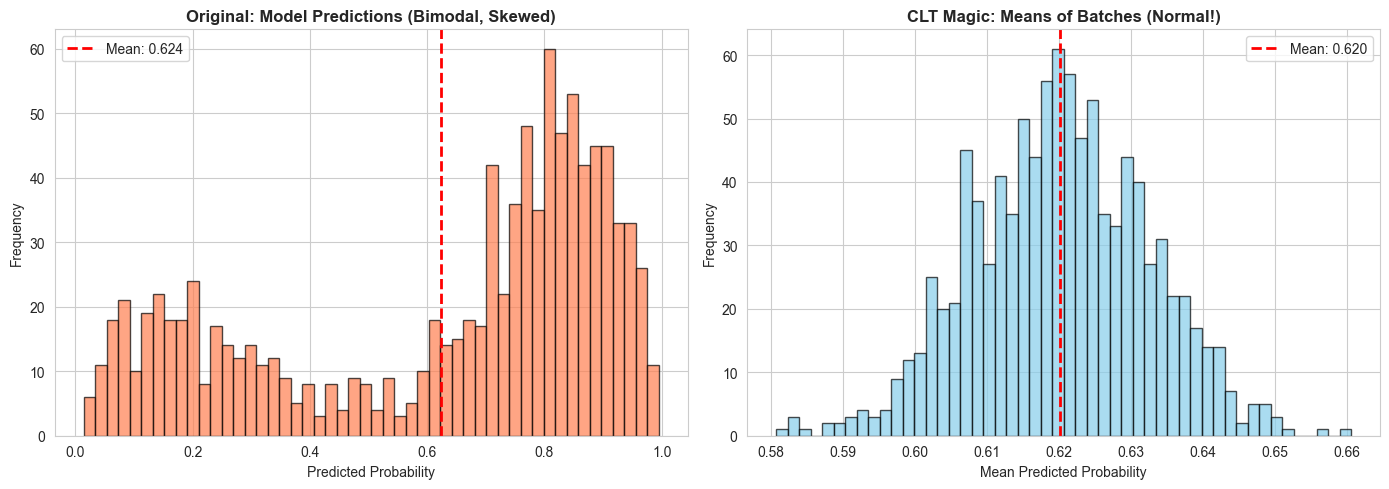

In [41]:
# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original distribution (NOT normal)
axes[0].hist(single_batch, bins=50, alpha=0.7, edgecolor='black', color='coral')
axes[0].set_title('Original: Model Predictions (Bimodal, Skewed)', fontsize=12, weight='bold')
axes[0].set_xlabel('Predicted Probability')
axes[0].set_ylabel('Frequency')
axes[0].axvline(single_batch.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {single_batch.mean():.3f}')
axes[0].legend()

# Distribution of MEANS (Normal!)
axes[1].hist(batch_means, bins=50, alpha=0.7, edgecolor='black', color='skyblue')
axes[1].set_title('CLT Magic: Means of Batches (Normal!)', fontsize=12, weight='bold')
axes[1].set_xlabel('Mean Predicted Probability')
axes[1].set_ylabel('Frequency')
axes[1].axvline(np.mean(batch_means), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(batch_means):.3f}')
axes[1].legend()

plt.tight_layout()
plt.show()

In [42]:
print("CENTRAL LIMIT THEOREM IN ACTION")
print("="*50)
print(f"Original distribution: Bimodal, skewed")
print(f"Mean of batch means: {np.mean(batch_means):.3f}")
print(f"Std of batch means: {np.std(batch_means):.3f}")
print(f"\n✓ Even though individual predictions are messy, the AVERAGE is reliable!")

CENTRAL LIMIT THEOREM IN ACTION
Original distribution: Bimodal, skewed
Mean of batch means: 0.620
Std of batch means: 0.012

✓ Even though individual predictions are messy, the AVERAGE is reliable!


Correlation vs Causation

In [43]:
# Generate confounded data
np.random.seed(42)
n = 1000

In [44]:
# Hidden confounder: User's age
age = np.random.uniform(20, 70, n)

In [45]:
# Feature 1: Time spent on app (correlated with age)
time_on_app = 50 - 0.5 * age + np.random.normal(0, 5, n)
time_on_app = np.clip(time_on_app, 5, 60)

In [46]:
# Target: Purchase (caused by age, NOT time_on_app)
purchase_prob = 1 / (1 + np.exp(-(0.05 * age - 2.5)))
purchase = np.random.binomial(1, purchase_prob)

In [47]:
# Create DataFrame
df = pd.DataFrame({
    'age': age,
    'time_on_app': time_on_app,
    'purchased': purchase
})

In [48]:
# Calculate correlations
print("CORRELATION ANALYSIS")
print("="*50)
print(df[['time_on_app', 'purchased']].corr())
print(f"\nTime on app vs Purchase: r = {df['time_on_app'].corr(df['purchased']):.3f}")
print(f"Age vs Purchase: r = {df['age'].corr(df['purchased']):.3f}")

CORRELATION ANALYSIS
             time_on_app  purchased
time_on_app     1.000000  -0.284518
purchased      -0.284518   1.000000

Time on app vs Purchase: r = -0.285
Age vs Purchase: r = 0.352
